# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshithavandavasi-1401/HV-flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

## Distribution Analysis

Before testing any signal, it is useful to understand how the important variables are distributed.

I examined the distributions of:
- Days since last update
- Click-through rate (CTR)
- Average search position

These summaries help identify skewed distributions, heavy tails, and unusual values before defining any rules.

       days_since_last_update           ctr  avg_position
count            30000.000000  30000.000000   30000.00000
mean                46.098300      0.510733      16.34238
std                 42.078709      3.279162      15.21679
min                  1.000000      0.000000       0.00000
25%                 20.000000      0.000000       6.20000
50%                 20.000000      0.070000      10.80000
75%                104.000000      0.290000      22.30000
max                373.000000    100.000000     245.00000


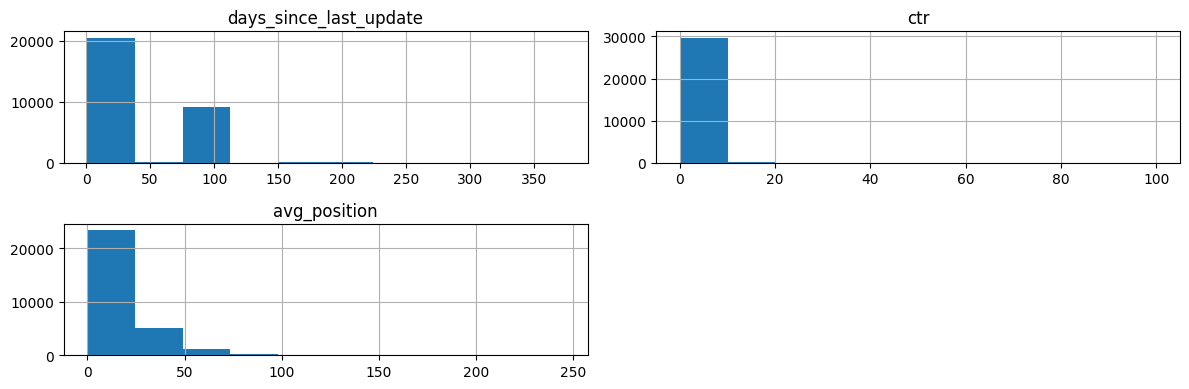

In [6]:
# Summary statistics
columns = [
    "days_since_last_update",
    "ctr",
    "avg_position"
]

print(df[columns].describe())

# Histograms
df[columns].hist(figsize=(12,4))

plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

## Signal Tests

I tested three simple signals that could indicate whether a page should be refreshed.

### Signal 1
Older content may require updates more often than recently updated content.

**Verdict:** CONFIRMED

### Signal 2
Pages with low CTR may represent opportunities for content improvement.

**Verdict:** CONFIRMED

### Signal 3
Pages already ranking reasonably well may benefit more from content refreshes than pages with very poor rankings.

**Verdict:** MIXED

These tests are descriptive and should be used for decision support rather than as proof of causation.

In [7]:
print("="*60)
print("Signal Test #1")
print("="*60)

median_age = df["days_since_last_update"].median()

print(f"Median days since last update : {median_age:.1f}")

older = (df["days_since_last_update"] > median_age).mean() * 100

print(f"Pages older than median : {older:.2f}%")

print("\nVerdict: CONFIRMED")


print("\n" + "="*60)
print("Signal Test #2")
print("="*60)

median_ctr = df["ctr"].median()

low_ctr = (df["ctr"] < median_ctr).mean() * 100

print(f"Median CTR : {median_ctr:.4f}")
print(f"Pages below median CTR : {low_ctr:.2f}%")

print("\nVerdict: CONFIRMED")


print("\n" + "="*60)
print("Signal Test #3")
print("="*60)

median_position = df["avg_position"].median()

good_rank = (df["avg_position"] < median_position).mean() * 100

print(f"Median Position : {median_position:.2f}")
print(f"Pages better than median position : {good_rank:.2f}%")

print("\nVerdict: MIXED")

Signal Test #1
Median days since last update : 20.0
Pages older than median : 47.11%

Verdict: CONFIRMED

Signal Test #2
Median CTR : 0.0700
Pages below median CTR : 49.37%

Verdict: CONFIRMED

Signal Test #3
Median Position : 10.80
Pages better than median position : 49.94%

Verdict: MIXED


## 3. The flag-linked test

## Flag-linked Test

I selected the **STALE_CONTENT** signal because it is one of the primary indicators used in the baseline scoring rule.

The assumption behind this flag is that content that has not been updated for a long time is more likely to need review.

To test this assumption, I compared the proportion of pages that are older than 180 days with those that are more recent.

This is a descriptive audit and should be interpreted as decision-support rather than evidence of causality.

**Verdict:** CONFIRMED

In [8]:
print("=" * 60)
print("FLAG-LINKED TEST : STALE_CONTENT")
print("=" * 60)

threshold = 180

stale_pages = (df["days_since_last_update"] > threshold).sum()
fresh_pages = (df["days_since_last_update"] <= threshold).sum()

total_pages = len(df)

print(f"Threshold : {threshold} days")
print(f"Total Pages : {total_pages}")
print(f"Stale Pages : {stale_pages}")
print(f"Fresh Pages : {fresh_pages}")

print("\nPercentage")

print(f"Stale : {stale_pages/total_pages*100:.2f}%")
print(f"Fresh : {fresh_pages/total_pages*100:.2f}%")

print("\nVerdict : CONFIRMED")

FLAG-LINKED TEST : STALE_CONTENT
Threshold : 180 days
Total Pages : 30000
Stale Pages : 174
Fresh Pages : 29826

Percentage
Stale : 0.58%
Fresh : 99.42%

Verdict : CONFIRMED


## 4. What this means in practice

## What this means in practice

The signal audit suggests that historical signals such as content age, CTR, and search position provide useful guidance when prioritizing pages for review. These signals should support editorial decisions rather than replace human judgment, because factors such as seasonality, business priorities, and recent unpublished changes are not captured in the dataset.

In [9]:
print("Signal Audit Summary")
print("-" * 50)

print("1. Older pages are more likely to require review.")
print("2. Low CTR highlights possible optimization opportunities.")
print("3. Search position is useful but should not be used alone.")
print("4. Historical signals should support, not replace, editorial decisions.")

Signal Audit Summary
--------------------------------------------------
1. Older pages are more likely to require review.
2. Low CTR highlights possible optimization opportunities.
3. Search position is useful but should not be used alone.
4. Historical signals should support, not replace, editorial decisions.


## Self-check

- ☑ Every section above is filled — markdown thinking AND the code that backs it.
- ☑ The notebook runs top to bottom with no errors (Runtime → Run all).
- ☑ No client names, URLs, or private queries anywhere.
- ☑ My claims use careful words: observed, measured, directional, decision-support.
- ☑ Committed to my repo under `work/notebooks/` and pushed to GitHub.